# Advent of Code 2023: Day 24 Part Two

This _felt_ like it should've been straightforward. My first attempt involved expressing a subset of the hailstones as a system of non-linear Diophantine equations, and then solving it via Newton's method ([the fastest method](https://www.youtube.com/watch?v=wrQA1_nei7w)). But this didn't work, not even on the example hailstones. (My simple implementation to solve a matrix equation with Gaussian elimination failed to transform the Jacobian matrix into upper triangular form.)

So it's time for a different approach.

## A Different Approach

First, let's establish what we know.

  - Position and velocity components are discrete; they must be integers.
  - Velocities should neither be zero nor infinite.
  - Collisions must occur when time is a positive integer.
  - Hailstones won't collide with each other.
  - We expect a unique rock solution to exist.

With that in mind, let's reduce the problem to its simplest form: one spatial dimension (plus time).

### One Spatial Dimension

Let's plot the position of hailstones (and rocks) across time. When two trajectories intersect at integer coordinates (and time is positive), we'll know they've collided.

If we start with a single hailstone, it should be apparent that we have practically infinite choices for the rock's starting position and velocity such that its resultant trajectory intersects at some valid point along the hailstone's trajectory.

In other words, we have infinite rock solutions.

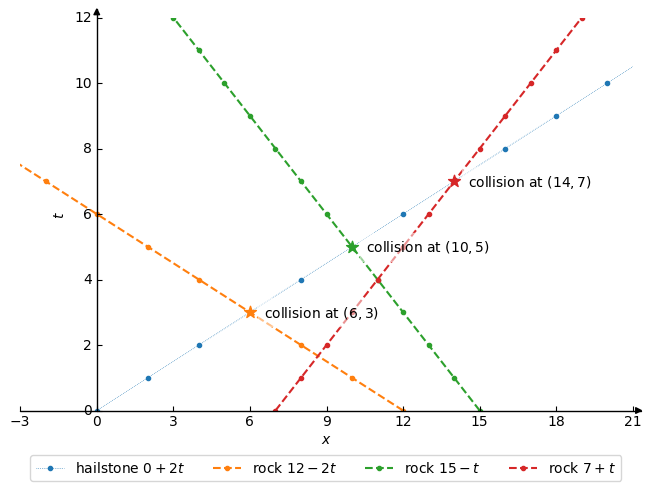

In [1]:
from collections.abc import Sequence
from typing import Any, NamedTuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axisartist.axislines import AxesZero
import numpy as np


class Coordinate1D(NamedTuple):
    x: int
    t: int

    def __str__(self) -> str:
        return f"$({self.x}, {self.t})$"


class Projectile1D(NamedTuple):
    # Starting position
    x0: int
    # Velocity
    dx: int

    def __call__(self, t: Any) -> Any:
        return self.x0 + (self.dx * t)

    def __str__(self) -> str:
        coeff_sign = "+" if self.dx >= 0 else "-"
        coeff_magnitude = abs(self.dx)
        pretty_coeff_magnitude = "" if coeff_magnitude == 1 else coeff_magnitude
        return f"${self.x0} {coeff_sign} {pretty_coeff_magnitude}t$"

    def get_collision(self, other: "Projectile1D") -> Optional[Coordinate1D]:
        assert self != other  # Lines musn't be coincident.
        if self.dx == other.dx:
            return None  # Lines are parallel.
        (t, remainder) = divmod(other.x0 - self.x0, self.dx - other.dx)
        if remainder != 0:
            return None  # No integer solution.
        if t <= 0:
            return None  # Intersection occurs before the start of time.
        return Coordinate1D(self(t), t)


def plot_hailstones_1d(
    *,
    xlim: tuple[int, int],
    tlim: int,
    hailstones: Sequence[Projectile1D],
    rocks: Sequence[Projectile1D],
) -> None:
    fig = plt.figure(layout="constrained")
    ax = fig.add_subplot(axes_class=AxesZero)
    for direction in ("left", "right", "bottom", "top"):
        ax.axis[direction].set_visible(False)
    for direction in ("xzero", "yzero"):
        ax.axis[direction].set_axisline_style("-|>")
        ax.axis[direction].set_visible(True)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_xlim(*xlim)
    ax.set_ylim(0, tlim)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    t = np.linspace(0, tlim, tlim + 1)
    for hailstone in hailstones:
        ax.plot(
            hailstone(t),
            t,
            label=f"hailstone {hailstone}",
            linestyle=":",
            linewidth=0.5,
            marker=".",
        )
    for rock in rocks:
        (line,) = ax.plot(
            rock(t), t, label=f"rock {rock}", linestyle="--", linewidth=1.5, marker="."
        )
        color = line.get_color()
        for hailstone in hailstones:
            if (collision := rock.get_collision(hailstone)) is None:
                continue
            ax.scatter(*collision, s=80, c=color, marker="*", zorder=2.5)
            ax.annotate(
                f"collision at {collision}",
                collision,
                xytext=(1, 0),
                textcoords="offset fontsize",
                backgroundcolor="#ffffff7f",
                verticalalignment="center",
            )

    fig.legend(loc="outside lower center", ncols=4)


plot_hailstones_1d(
    xlim=(-3, 21),
    tlim=12,
    hailstones=(Projectile1D(0, 2),),
    rocks=(Projectile1D(12, -2), Projectile1D(15, -1), Projectile1D(7, 1)),
)

What about two hailstones? (Let's assume their trajectories aren't coincident.)

If we _weren't_ limited to integer solutions, we could convince ourselves pretty easily that we have infinite ways to draw a rock trajectory such that it intersects the two hailstones' trajectories.

But what about integer solutions? We would need to pick a point on each hailstone's trajectory where the resultant gradient between the two points is $\frac{1}{n}$, where $n \in \mathbb{Z}^*$. Is this always possible? Is this infinitely possible?

Given two hailstones ($x = a + bt$ and $x = c + dt$, where $a, c \in \mathbb{Z}$, $b, d \in \mathbb{Z}^*$, and $b \ne d$) and two points in time ($t_1$ and $t_1 + e$, where $t_1, e \in \mathbb{Z}^+$), we can represent this gradient as follows.

$$
\begin{align}
m &= \frac{(t_1 + e) - t_1}{(c + d(t_1 + e)) - (a + bt_1)} \\
&= \frac{e}{c + dt_1 + de - a - bt_1} \\
&= \frac{1}{d + \frac{(d - b)t_1 + c - a}{e}}
\end{align}
$$

Thus, for the denominator to be a non-zero integer, we need to pick $t_1$ and $e$ to satisfy the linear congruence $(d - b)t_1 \equiv a - c \pmod e$ (with the additional constraint that $a + bt_1 \ne c + d(t_1 + e)$). This means picking $e$ such that $\gcd(d - b, e) \mid a - c$. At the very least, we have infinite ways to pick $e$ such that $\gcd(d - b, e) = 1$, and since $1 \mid a - c$, we in turn have infinite ways to pick $t_1$ to satisfy the linear congruence.

So we still have infinite rock solutions.

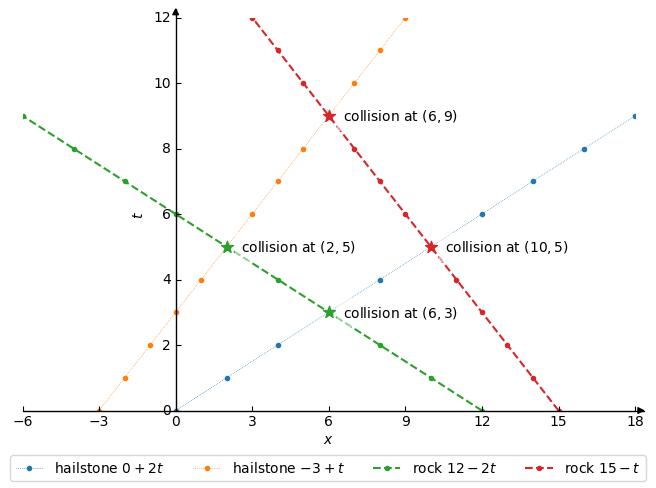

In [2]:
plot_hailstones_1d(
    xlim=(-6, 18),
    tlim=12,
    hailstones=(Projectile1D(0, 2), Projectile1D(-3, 1)),
    rocks=(Projectile1D(12, -2), Projectile1D(15, -1)),
)

If we introduce a third hailstone, we could contrive for its trajectory to keep some of the infinite rock solutions (from the first two hailstones) possible. But since we're expecting a unique solution to exist, we could also contrive for its trajectory to collapse those infinite possibilities down to one.

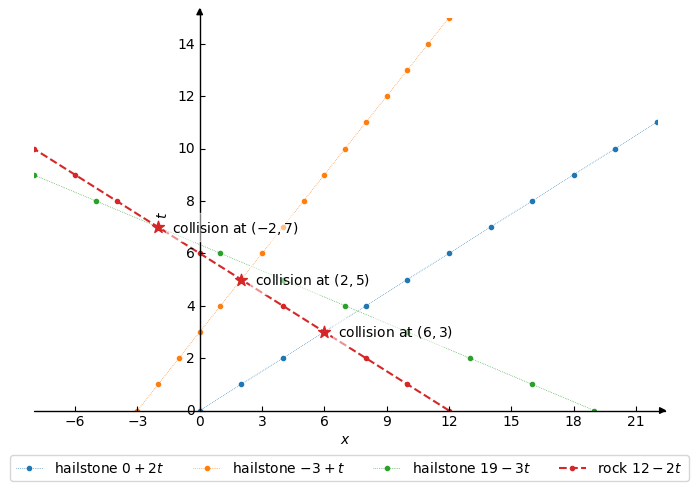

In [3]:
plot_hailstones_1d(
    xlim=(-8, 22),
    tlim=15,
    hailstones=(Projectile1D(0, 2), Projectile1D(-3, 1), Projectile1D(19, -3)),
    rocks=(Projectile1D(12, -2),),
)

Thus, for one spatial dimension (plus time), it seems we need at least three hailstones to contrive a unique rock solution.

Now let's introduce a second spatial dimension.

### Two Spatial Dimensions

It should be obvious that one hailstone still gives us infinite rock solutions.

The trajectories of two hailstones would form a plane upon which infinite rock solutions also lie.

If we add a third hailstone, we'd expect for its trajectory to intersect this plane and constrain solutions, but not necessarily down to a unique rock solution.

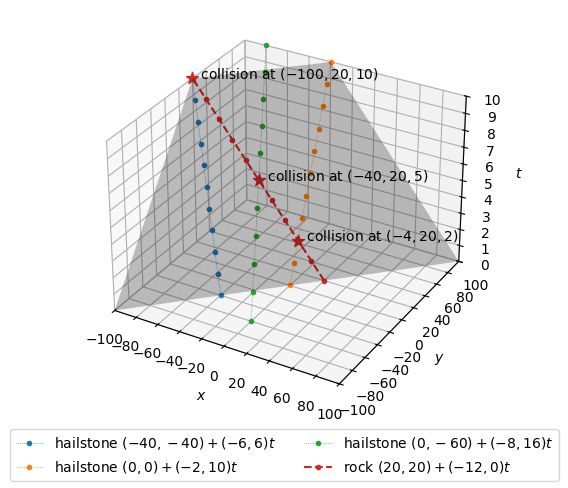

In [4]:
class Coordinate2D(NamedTuple):
    x: int
    y: int
    t: int

    def __str__(self) -> str:
        return f"$({self.x}, {self.y}, {self.t})$"


class Plane2D(NamedTuple):
    a: int  # Normal's x component
    b: int  # Normal's y component
    c: int  # Normal's t component
    d: int  # Constant

    def __call__(self, x: Any, y: Any) -> Any:
        assert self.c != 0
        return (self.d - (self.a * x) - (self.b * y)) / self.c


class Projectile2D(NamedTuple):
    # Starting position
    x0: int
    y0: int
    # Velocity
    dx: int
    dy: int

    def __call__(self, t: Any) -> tuple[Any, Any]:
        return (self.x0 + (self.dx * t), self.y0 + (self.dy * t))

    def __str__(self) -> str:
        return f"$({self.x0}, {self.y0}) + ({self.dx}, {self.dy})t$"

    def get_collision(
        self, other: "Projectile2D", allow_negative_time: bool = False
    ) -> Optional[Coordinate2D]:
        assert self != other  # Lines mustn't be coincident.
        if self.dx != other.dx:
            (t, remainder) = divmod(other.x0 - self.x0, self.dx - other.dx)
        elif self.dy != other.dy:
            (t, remainder) = divmod(other.y0 - self.y0, self.dy - other.dy)
        else:
            return None  # Lines are parallel.
        if remainder != 0:
            return None  # No integer solution.
        if (xy := self(t)) != other(t):
            return None  # Lines intersect when projected onto one coordinate plane, but not the other.
        if t <= 0 and not allow_negative_time:
            return None  # Intersection occurs before the start of time.
        return Coordinate2D(*xy, t)

    def get_plane(self, other: "Projectile2D") -> Plane2D:
        assert self != other  # Lines mustn't be coincident.
        if (self.dx, self.dy) != (other.dx, other.dy):
            # Lines aren't parallel. Find point of intersection. (For numerical precision, we require integer coordinates.)
            assert (
                collision := self.get_collision(other, allow_negative_time=True)
            ) is not None
            (px, py, pt) = collision
            (ux, uy, ut) = (self.dx, self.dy, 1)
            (vx, vy, vt) = (other.dx, other.dy, 1)
        else:
            # Lines are parallel.
            (px, py, pt) = (self.x0, self.y0, 0)
            (ux, uy, ut) = (self.dx, self.dy, 1)
            (vx, vy, vt) = (other.x0 - self.x0, other.y0 - self.y0, 0)
        # Cross product
        nx = (uy * vt) - (ut * vy)
        ny = (ut * vx) - (ux * vt)
        nt = (ux * vy) - (uy * vx)
        constant = (nx * px) + (ny * py) + (nt * pt)
        return Plane2D(nx, ny, nt, constant)


def plot_hailstones_2d(
    *,
    xlim: tuple[int, int],
    ylim: tuple[int, int],
    tlim: int,
    hailstones: Sequence[Projectile2D],
    rocks: Sequence[Projectile2D],
    subdivisions: int = 10,
) -> None:
    fig = plt.figure(layout="constrained")
    ax = fig.add_subplot(projection="3d")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_zlabel("$t$")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(0, tlim)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.zaxis.set_major_locator(MaxNLocator(integer=True))

    t = np.linspace(0, tlim, tlim + 1)
    if len(hailstones) >= 2:
        plane = hailstones[0].get_plane(hailstones[1])
        plane_x = np.linspace(*xlim, ((xlim[1] - xlim[0]) * subdivisions) + 1)
        plane_y = np.linspace(*ylim, ((ylim[1] - ylim[0]) * subdivisions) + 1)
        (plane_xs, plane_ys) = np.meshgrid(plane_x, plane_y, sparse=True)
        plane_zs = plane(plane_xs, plane_ys)
        plane_zs[(plane_zs < 0) | (plane_zs > tlim)] = np.nan
        ax.plot_surface(plane_xs, plane_ys, plane_zs, color="#0000003f")
    for hailstone in hailstones:
        ax.plot(
            *hailstone(t),
            t,
            label=f"hailstone {hailstone}",
            linestyle=":",
            linewidth=0.5,
            marker=".",
        )
    for rock in rocks:
        (line,) = ax.plot(
            *rock(t), t, label=f"rock {rock}", linestyle="--", linewidth=1.5, marker="."
        )
        color = line.get_color()
        for hailstone in hailstones:
            if (collision := rock.get_collision(hailstone)) is None:
                continue
            ax.scatter(*collision, s=80, c=color, marker="*")
            ax.text(*collision, f"  collision at {collision}")

    fig.legend(loc="outside lower center", ncols=2)


plot_hailstones_2d(
    xlim=(-100, 100),
    ylim=(-100, 100),
    tlim=10,
    hailstones=(
        Projectile2D(-40, -40, -6, 6),
        Projectile2D(0, 0, -2, 10),
        Projectile2D(0, -60, -8, 16),
    ),
    rocks=(Projectile2D(20, 20, -12, 0),),
)

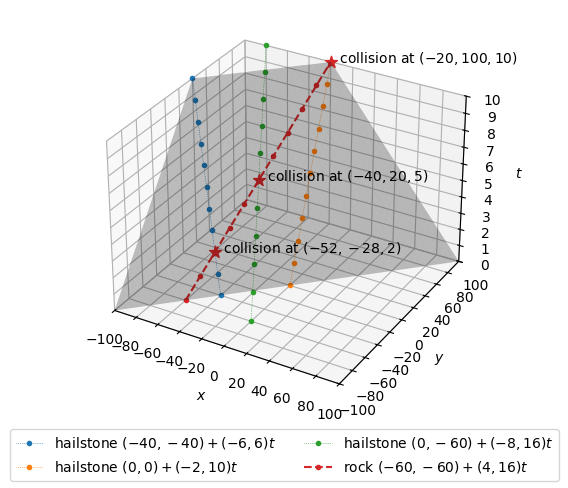

In [5]:
plot_hailstones_2d(
    xlim=(-100, 100),
    ylim=(-100, 100),
    tlim=10,
    hailstones=(
        Projectile2D(-40, -40, -6, 6),
        Projectile2D(0, 0, -2, 10),
        Projectile2D(0, -60, -8, 16),
    ),
    rocks=(Projectile2D(-60, -60, 4, 16),),
)

To constrain possibilities down to a unique rock solution, we need a fourth hailstone.

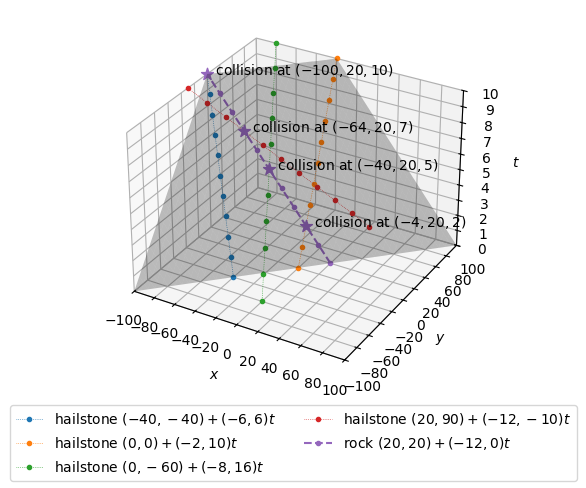

In [6]:
plot_hailstones_2d(
    xlim=(-100, 100),
    ylim=(-100, 100),
    tlim=10,
    hailstones=(
        Projectile2D(-40, -40, -6, 6),
        Projectile2D(0, 0, -2, 10),
        Projectile2D(0, -60, -8, 16),
        Projectile2D(20, 90, -12, -10),
    ),
    rocks=(Projectile2D(20, 20, -12, 0),),
)

Thus, for two spatial dimensions (plus time), it seems like we need at least four hailstones to contrive a unique solution. The first two hailstones' trajectories form a plane, and the points of intersection between this plane and the next two hailstones' trajectories form the unique rock solution's trajectory.

We've now built up the intuition to tackle a third spatial dimension.

### Three Spatial Dimensions

If one spatial dimension (plus time) required three hailstones, and two spatial dimensions (plus time) required four hailstones, we can expect three spatial dimensions (plus time) to require five hailstones.

Following the methodology for two spatial dimensions (plus time), we take the first three hailstones' trajectories to form a hyperplane, then the points of intersection between this hyperplane and the next two hailstones' trajectories to form the unique rock solution's trajectory.